# Detecção de Fraudes em Cartões de Crédito - Análise Exploratória

Este notebook realiza uma análise exploratória dos dados de transações de cartões de crédito para entender o problema de detecção de fraudes.

## 1. Import Required Libraries

Import necessary libraries such as pandas, numpy, scikit-learn, imbalanced-learn, xgboost, matplotlib, seaborn, shap, and joblib.

In [8]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurações de plot
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load and Explore the Dataset

Load the credit card dataset from the provided URL, perform basic validations (e.g., check for 'Class' column, null values, dataset dimensions), and conduct exploratory data analysis including summary statistics and class distribution.

Carregando dataset...
Dimensões do dataset: 284807 linhas x 31 colunas

Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Nenhum valor nulo encontrado.

Estatísticas descritivas:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max   

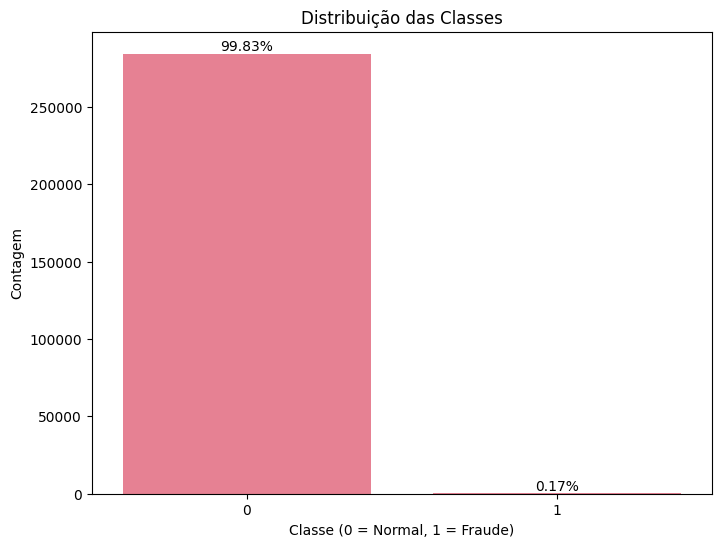


Proporção de fraudes: 0.1727%
Proporção de transações normais: 99.8273%


In [9]:
# Load and Explore the Dataset
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

print("Carregando dataset...")
df = pd.read_csv(DATA_URL)

# Validações básicas
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")

# Verificar coluna Class
if 'Class' not in df.columns:
    raise ValueError("Coluna 'Class' não encontrada no dataset")

# Verificar valores nulos
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    print(f"\nValores nulos encontrados:\n{null_counts[null_counts > 0]}")
else:
    print("\nNenhum valor nulo encontrado.")

# Estatísticas básicas
print(f"\nEstatísticas descritivas:")
print(df.describe())

# Distribuição da classe alvo
print(f"\nDistribuição da classe alvo:")
class_dist = df['Class'].value_counts(normalize=True) * 100
print(class_dist)

# Plot da distribuição de classes
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Class')
plt.title('Distribuição das Classes')
plt.xlabel('Classe (0 = Normal, 1 = Fraude)')
plt.ylabel('Contagem')

# Adicionar percentuais nas barras
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

print(f"\nProporção de fraudes: {class_dist[1]:.4f}%")
print(f"Proporção de transações normais: {class_dist[0]:.4f}%")

## 3. Data Preprocessing and Feature Engineering

Create new features like Amount_log using np.log1p, separate features (X) and target (y), and prepare data for modeling while avoiding data leakage.

Feature 'Amount_log' criada
X shape: (284807, 31)
y distribution: {0: 284315, 1: 492}


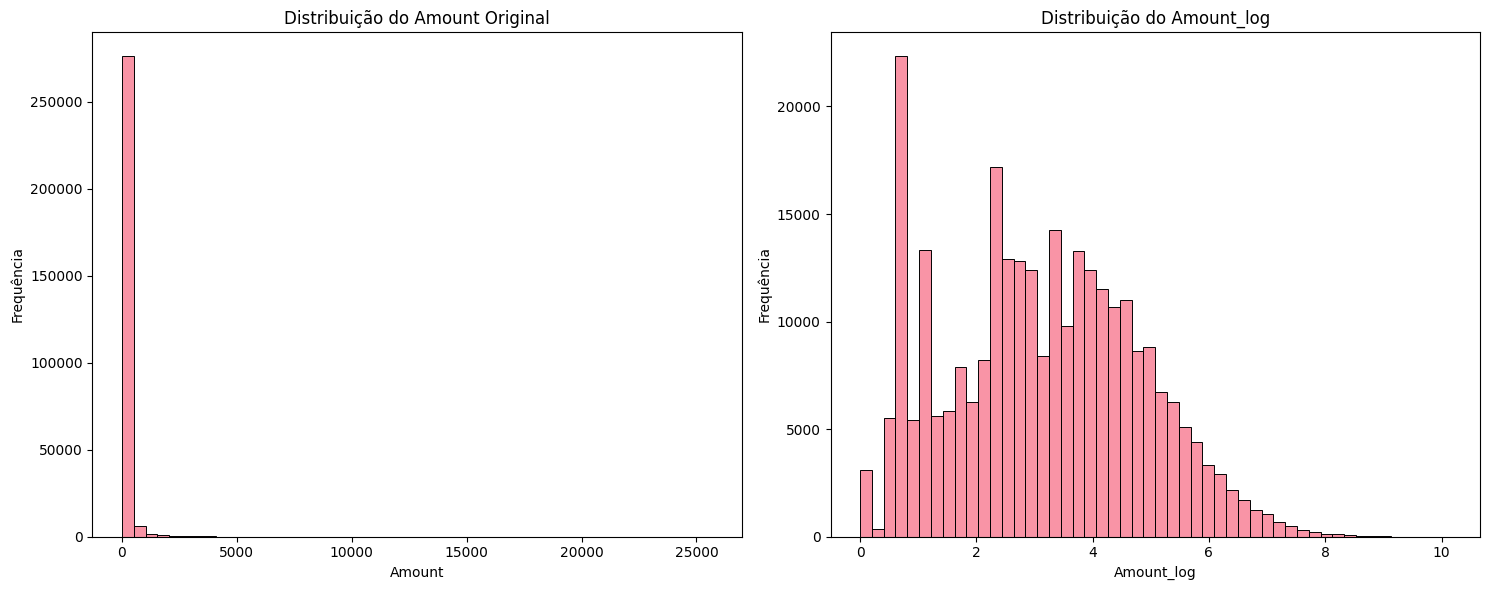

Correlação entre Amount e Amount_log: 0.5520


In [10]:
# Data Preprocessing and Feature Engineering
# Criar feature Amount_log
df['Amount_log'] = np.log1p(df['Amount'])

print("Feature 'Amount_log' criada")

# Separar features e target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")

# Visualizar distribuição do Amount original vs log
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Amount original
sns.histplot(df['Amount'], bins=50, ax=ax1)
ax1.set_title('Distribuição do Amount Original')
ax1.set_xlabel('Amount')
ax1.set_ylabel('Frequência')

# Amount log
sns.histplot(df['Amount_log'], bins=50, ax=ax2)
ax2.set_title('Distribuição do Amount_log')
ax2.set_xlabel('Amount_log')
ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Correlação entre Amount e Amount_log
correlation = df[['Amount', 'Amount_log']].corr()
print(f"Correlação entre Amount e Amount_log: {correlation.iloc[0,1]:.4f}")

## 4. Split Data into Train and Test Sets

Use train_test_split with test_size=0.3, random_state=42, and stratify=y to ensure balanced splits.

In [11]:
# Split Data into Train and Test Sets
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição em treino:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nDistribuição em teste:")
print(y_test.value_counts(normalize=True) * 100)

Treino: 199364 amostras
Teste: 85443 amostras

Distribuição em treino:
Class
0    99.827451
1     0.172549
Name: proportion, dtype: float64

Distribuição em teste:
Class
0    99.826785
1     0.173215
Name: proportion, dtype: float64


## 5. Train Machine Learning Models

Train at least three models: LogisticRegression with class_weight='balanced' in a Pipeline with StandardScaler, RandomForestClassifier with class_weight='balanced', and XGBClassifier with calculated scale_pos_weight. Use imblearn.pipeline for SMOTE if applied.

In [12]:
# Train Machine Learning Models
if 'X' not in globals() or 'y' not in globals() or np.isscalar(y):
    if 'df' in globals() and 'Class' in df.columns:
        X = df.drop('Class', axis=1)
        y = df['Class']
        print("Reconstruindo X e y a partir do DataFrame df.")
    else:
        raise ValueError("As variáveis X e y não estão definidas corretamente. Execute a seção de pré-processamento antes de treinar os modelos.")

if 'X_train' not in globals() or 'y_train' not in globals():
    print("Variáveis de treino não encontradas. Criando divisão treino/teste...")
    RANDOM_STATE = 42
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
    )
    print(f"Treino: {X_train.shape[0]} amostras")
    print(f"Teste: {X_test.shape[0]} amostras")

# Calcular scale_pos_weight para XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight para XGBoost: {scale_pos_weight:.2f}")

# Modelo 1: LogisticRegression com Pipeline
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Modelo 2: RandomForestClassifier
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=10
)

# Modelo 3: XGBClassifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

# Treinar modelos
print("Treinando LogisticRegression...")
lr_pipeline.fit(X_train, y_train)

print("Treinando RandomForest...")
rf_model.fit(X_train, y_train)

print("Treinando XGBoost...")
xgb_model.fit(X_train, y_train)

models = {
    'LogisticRegression': lr_pipeline,
    'RandomForest': rf_model,
    'XGBoost': xgb_model
}

print("Modelos treinados com sucesso!")

Scale pos weight para XGBoost: 578.55
Treinando LogisticRegression...
Treinando RandomForest...
Treinando XGBoost...
Modelos treinados com sucesso!


## 6. Evaluate Models and Compare Performance

Evaluate each model using metrics like recall, precision, f1-score for class 1, ROC-AUC, PR-AUC, confusion matrix, and compare them to select the best based on F1-score or PR-AUC.

In [13]:
# Evaluate Models and Compare Performance
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    return {
        'precision_class_1': precision,
        'recall_class_1': recall,
        'f1_class_1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

# Avaliar todos os modelos
results = {}
for name, model in models.items():
    print(f"Avaliando {name}...")
    results[name] = evaluate_model(model, X_test, y_test, name)

# Comparar modelos
comparison = pd.DataFrame(results).T
comparison = comparison.round(4)
print("\nComparação de Modelos:")
print(comparison)

# Selecionar melhor modelo (baseado em F1 da classe 1)
best_model_name = comparison['f1_class_1'].idxmax()
best_model = models[best_model_name]
print(f"\nMelhor modelo: {best_model_name} (F1 classe 1: {comparison.loc[best_model_name, 'f1_class_1']:.4f})")

Avaliando LogisticRegression...
Avaliando RandomForest...
Avaliando XGBoost...

Comparação de Modelos:
                    precision_class_1  recall_class_1  f1_class_1  roc_auc  \
LogisticRegression             0.0655          0.8784      0.1219   0.9678   
RandomForest                   0.8370          0.7635      0.7986   0.9598   
XGBoost                        0.7800          0.7905      0.7852   0.9592   

                    pr_auc  
LogisticRegression  0.7024  
RandomForest        0.7805  
XGBoost             0.8274  

Melhor modelo: RandomForest (F1 classe 1: 0.7986)


## 7. Threshold Analysis

Test different thresholds (0.1, 0.2, 0.3, 0.4, 0.5) on the best model, calculate precision, recall, f1-score, and confusion matrix for each, and select the optimal threshold for balancing recall and precision.

Análise de Threshold:
   threshold  precision    recall  f1_score   tp   fp     tn  fn
0        0.1   0.138950  0.858108  0.239171  127  787  84508  21
1        0.2   0.448029  0.844595  0.585480  125  154  85141  23
2        0.3   0.623711  0.817568  0.707602  121   73  85222  27
3        0.4   0.766234  0.797297  0.781457  118   36  85259  30
4        0.5   0.837037  0.763514  0.798587  113   22  85273  35


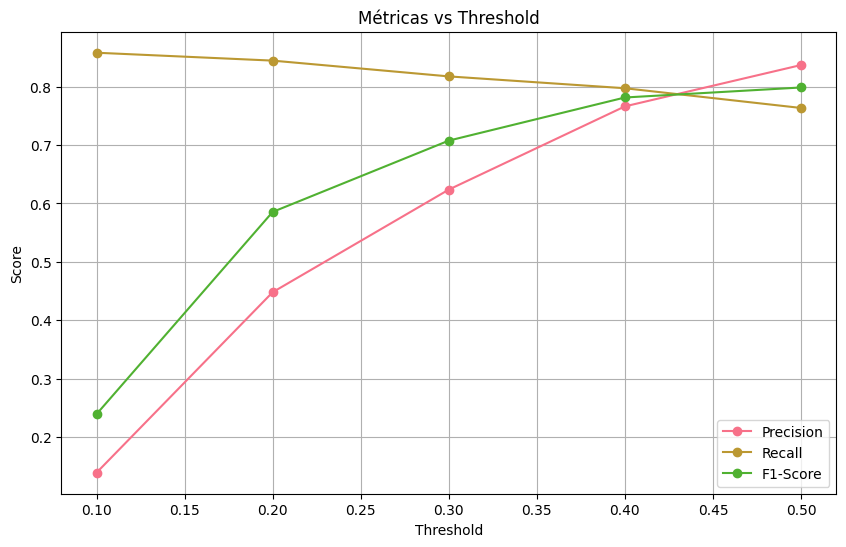

Melhor threshold: 0.5 (F1: 0.7986)


In [14]:
# Threshold Analysis
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)

    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

threshold_df = pd.DataFrame(threshold_results)
print("Análise de Threshold:")
print(threshold_df)

# Plot threshold vs métricas
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', marker='o')
ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', marker='o')
ax.plot(threshold_df['threshold'], threshold_df['f1_score'], label='F1-Score', marker='o')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Métricas vs Threshold')
ax.legend()
ax.grid(True)
plt.show()

# Selecionar melhor threshold (equilíbrio entre recall e precision)
best_threshold_idx = threshold_df['f1_score'].idxmax()
best_threshold = threshold_df.loc[best_threshold_idx, 'threshold']
print(f"Melhor threshold: {best_threshold} (F1: {threshold_df.loc[best_threshold_idx, 'f1_score']:.4f})")

## 8. Generate Plots and Visualizations

Create and save plots including confusion matrix, ROC curve, precision-recall curve, and feature importance for the best model.

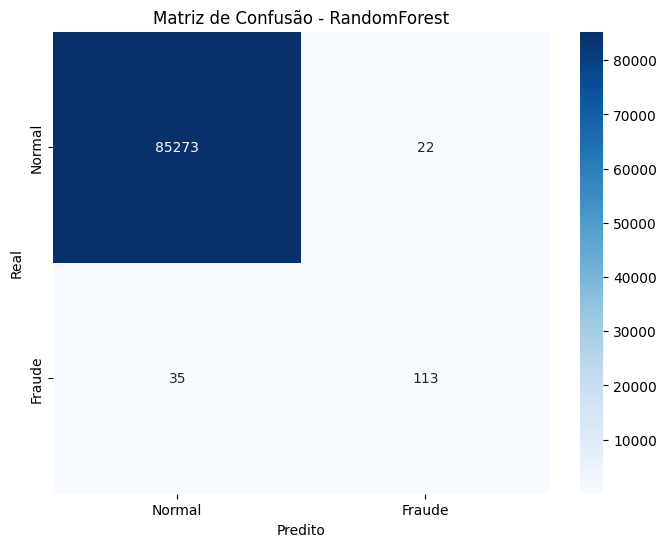

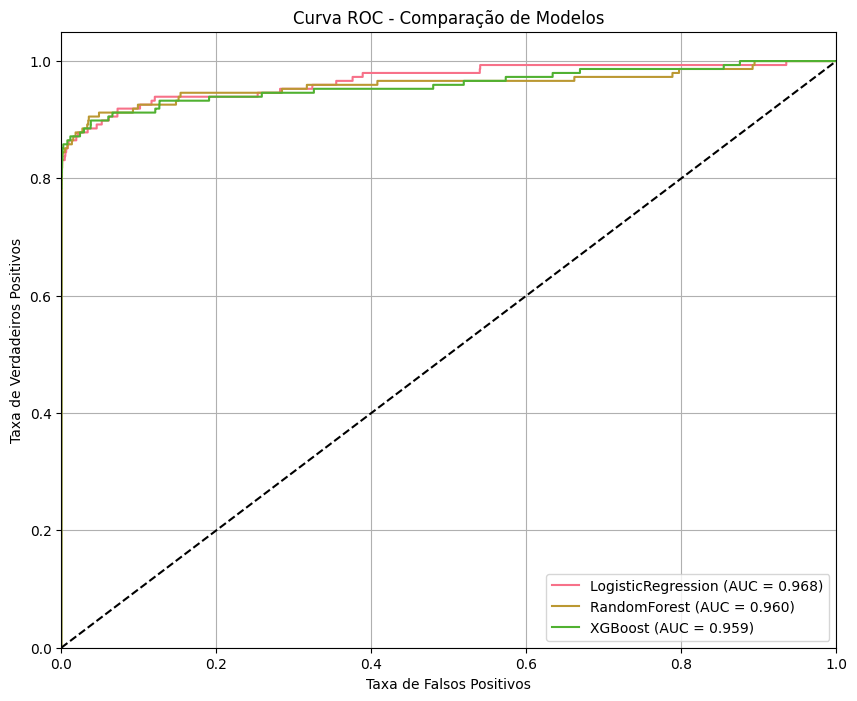

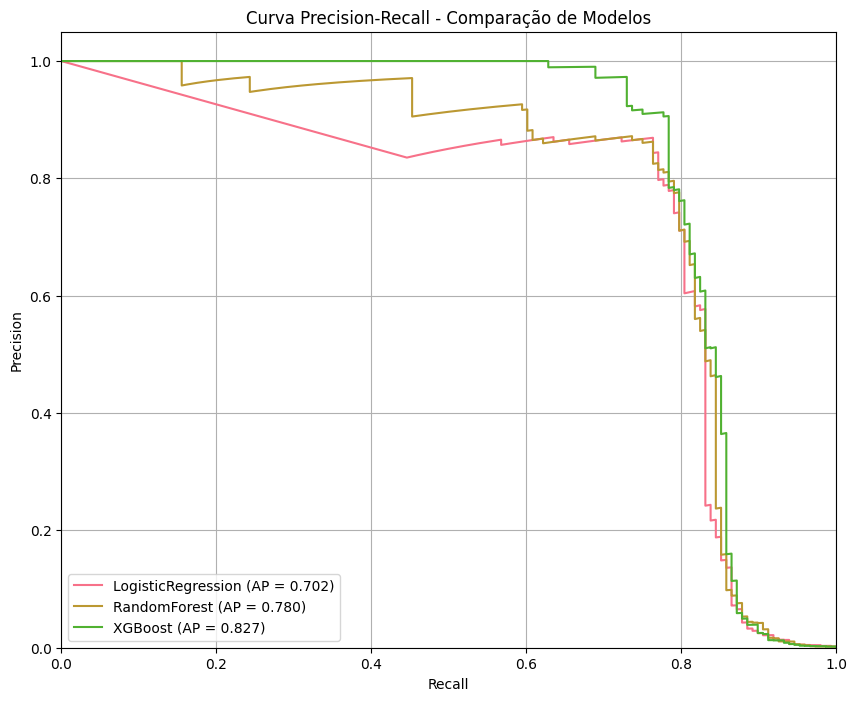

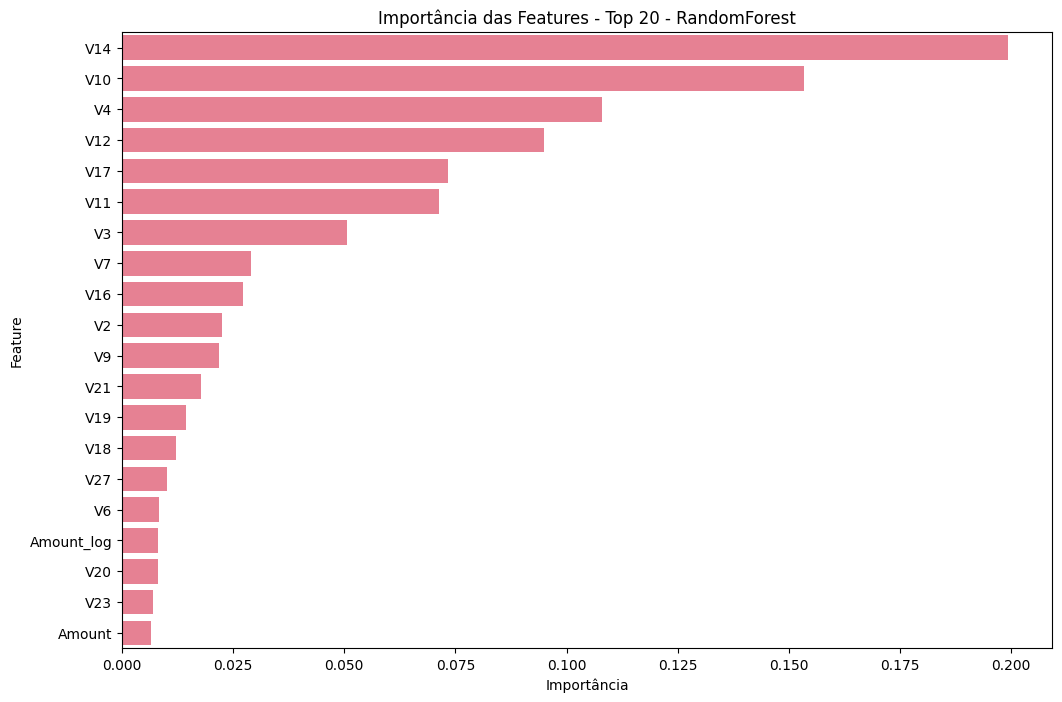

In [15]:
# Generate Plots and Visualizations
# Matriz de confusão
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title(f'Matriz de Confusão - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# Curva ROC
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação de Modelos')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Curva Precision-Recall
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.plot(recall_curve, precision_curve, label=f'{name} (AP = {average_precision_score(y_test, y_pred_proba):.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Comparação de Modelos')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Importância de features (para modelos que suportam)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = abs(best_model.coef_[0]) if len(best_model.coef_.shape) > 1 else abs(best_model.coef_)
else:
    importances = None

if importances is not None:
    feature_names = X_test.columns
    feature_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_imp)
    plt.title(f'Importância das Features - Top 20 - {best_model_name}')
    plt.xlabel('Importância')
    plt.ylabel('Feature')
    plt.show()
else:
    print(f"Modelo {best_model_name} não suporta importância de features")

## 9. Model Explainability with SHAP

Use SHAP to explain the XGBoost model, generate a summary plot, and handle any errors gracefully.

In [16]:
# Model Explainability with SHAP
try:
    if str(type(best_model)).endswith("XGBClassifier'>"):
        print("Gerando explicação SHAP para XGBoost...")

        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, show=False)
        plt.title('SHAP Summary Plot - XGBoost')
        plt.tight_layout()
        plt.show()

        print("Explicação SHAP gerada com sucesso.")
    else:
        print("SHAP implementado apenas para XGBoost. Pulando análise.")

except ImportError:
    print("Biblioteca SHAP não instalada.")
except Exception as e:
    print(f"Erro na análise SHAP: {e}")
    print("Continuando sem análise SHAP...")

SHAP implementado apenas para XGBoost. Pulando análise.


## 10. Save Model and Generate Report

Save the best model to a file, generate a text report with evaluation metrics, and save threshold analysis to a CSV.

In [17]:
# Save Model and Generate Report
import os

# Criar diretórios se não existirem
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Salvar melhor modelo
joblib.dump(best_model, 'models/best_model.joblib')
print("Modelo salvo em models/best_model.joblib")

# Gerar relatório
with open('reports/model_report.txt', 'w', encoding='utf-8') as f:
    f.write("=== RELATÓRIO DE DETECÇÃO DE FRAUDES ===\n\n")
    f.write(f"Melhor modelo: {best_model_name}\n\n")
    f.write("COMPARAÇÃO DE MODELOS:\n")
    f.write(comparison.to_string())
    f.write("\n\nMÉTRICAS DO MELHOR MODELO:\n")
    for metric, value in results[best_model_name].items():
        f.write(f"{metric}: {value:.4f}\n")
    f.write(f"\nMelhor threshold: {best_threshold}\n")

print("Relatório salvo em reports/model_report.txt")

# Salvar análise de threshold
threshold_df.to_csv('reports/threshold_analysis.csv', index=False)
print("Análise de threshold salva em reports/threshold_analysis.csv")

print("\n=== Análise concluída! ===")

Modelo salvo em models/best_model.joblib
Relatório salvo em reports/model_report.txt
Análise de threshold salva em reports/threshold_analysis.csv

=== Análise concluída! ===
